# Predicting Customer Churn in Nigeria's Telecom Industry Using Machine Learning

## An End-to-End Business Analytics and Machine Learning Case Study

# PART 1 - PROJECT INTRODUCTION

## 1. Business Problem
In Nigeria's highly competitive telecommunications market, subscriber churn represents a significant challenge for network providers. Without warning, valuable data subscribers discontinue their services, leading to revenue loss and increased customer acquisition costs. Proactively identifying customers at risk of churning is crucial for maintaining profitability and market share.

## 2. Project Objective
The primary objective of this project is to develop a robust machine learning model capable of predicting which data subscribers are likely to churn based on their usage data. The solution aims to provide a tabular input, a churn probability score, identify top churn drivers, and offer a comprehensive model evaluation.

## 3. Why Customer Churn Matters to Telecom Companies
Customer churn directly impacts a telecom company's bottom line. Losing existing customers is often more expensive than retaining them, as new customer acquisition involves significant marketing and operational costs. High churn rates can also indicate underlying issues with service quality, pricing, or customer satisfaction, leading to a damaged brand reputation. In the Nigerian context, where market penetration is high and competition is fierce, even small reductions in churn can lead to substantial financial benefits and improved long-term sustainability.

## 4. Machine-Learning Approach
This project employs a supervised machine learning approach to address the churn prediction problem. We leverage historical customer data, including usage patterns, demographics, and service interactions, to train predictive models. Multiple classification algorithms are compared and evaluated to identify the most effective model for accurately forecasting churn.

## 5. Expected Business Value
By accurately predicting customer churn, telecom companies can:
*   **Reduce Revenue Loss:** Proactively intervene with retention strategies for at-risk customers.
*   **Optimize Marketing Spend:** Target retention campaigns more effectively, rather than broadly.
*   **Improve Customer Satisfaction:** Address underlying issues before customers decide to leave.
*   **Enhance Strategic Planning:** Gain insights into factors driving churn to inform product development and service improvements.
*   **Increase Customer Lifetime Value:** Retain high-value customers for longer durations.

## 6. Project Scope
This project covers the entire machine learning lifecycle, including:
*   **Data Loading and Preprocessing:** Handling raw data, cleaning, and transformation.
*   **Exploratory Data Analysis (EDA):** Understanding data distributions, relationships, and patterns.
*   **Feature Engineering:** Creating new, meaningful features from existing data.
*   **Model Development and Evaluation:** Training and comparing various machine learning models.
*   **Model Selection and Threshold Tuning:** Optimizing the best-performing model for the business objective.
*   **Explainable AI (XAI):** Understanding why the model makes certain predictions.
*   **Customer Risk Segmentation:** Categorizing customers based on churn probability.
*   **Business Insights and Recommendations:** Deriving actionable insights for retention strategies.
*   **Streamlit Application Development:** Building an interactive web application for predictions and insights.

## 7. Limitations
*   **Data Availability:** The predictions are limited by the scope and quality of the provided dataset (974 subscribers). Factors not present in the data (e.g., competitor actions, macroeconomic conditions) cannot be modeled.
*   **Model Discrimination:** Even after model comparison and tuning, the best model achieves a ROC-AUC of approximately 0.69, meaning it has moderate, not strong, ability to separate churners from non-churners. This should be communicated honestly alongside any deployment.
*   **Generalizability:** While focused on the Nigerian telecom industry, the specific findings and model may not be directly transferable to other markets or industries without further validation.
*   **Causal Inference:** The model identifies correlations, not necessarily direct causation. Interventions based on predictions should be carefully designed and tested.
*   **Dynamic Nature of Churn:** Customer behavior and market conditions can change rapidly, requiring periodic model retraining and updates.

# PART 2 - LOAD THE DATA

In this section, we locate the dataset, load it into a pandas DataFrame, and perform an initial inspection of its structure.

In [1]:
import pandas as pd
import os
import zipfile

# 1. Locate the file
file_path = '/content/mtn_customer_churn.csv'

# 2. Extract if it were a ZIP (Handle robustly)
if file_path.endswith('.zip'):
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        zip_ref.extractall('/content/extracted_data')
    # Re-scan for CSV in extracted folder
    extracted_files = os.listdir('/content/extracted_data')
    csv_files = [f for f in extracted_files if f.endswith('.csv')]
    if csv_files:
        file_path = os.path.join('/content/extracted_data', csv_files[0])

# 3. Load into pandas
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded: {file_path}")
except Exception as e:
    print(f"Error loading file: {e}")

# 4. Display metadata
print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

Successfully loaded: /content/mtn_customer_churn.csv

--- Dataset Shape ---
(974, 17)

--- Data Types ---
Customer ID                      str
Full Name                        str
Date of Purchase                 str
Age                            int64
State                            str
MTN Device                       str
Gender                           str
Satisfaction Rate              int64
Customer Review                  str
Customer Tenure in months      int64
Subscription Plan                str
Unit Price                     int64
Number of Times Purchased      int64
Total Revenue                  int64
Data Usage                   float64
Customer Churn Status            str
Reasons for Churn                str
dtype: object

--- First 5 Rows ---


,Customer ID,Full Name,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn
0,CUST0001,Ngozi Berry,Jan-25,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,35000,19,665000,44.48,Yes,Relocation
1,CUST0002,Zainab Baker,Mar-25,16,Abuja (FCT),Mobile SIM Card,Female,2,Fair,22,12.5GB Monthly Plan,5500,12,66000,19.79,Yes,Better Offers from Competitors
2,CUST0003,Saidu Evans,Mar-25,21,Sokoto,5G Broadband Router,Male,1,Poor,60,150GB FUP Monthly Unlimited,20000,8,160000,9.64,No,NaN
3,CUST0003,Saidu Evans,Mar-25,21,Sokoto,Mobile SIM Card,Male,1,Poor,60,1GB+1.5mins Daily Plan,500,8,4000,197.05,No,NaN
4,CUST0003,Saidu Evans,Mar-25,21,Sokoto,Broadband MiFi,Male,1,Poor,60,30GB Monthly Broadband Plan,9000,15,135000,76.34,No,NaN



--- Last 5 Rows ---


,Customer ID,Full Name,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn
969,CUST0498,Shehu Harris,Jan-25,72,Osun,4G Router,Female,3,Good,42,25GB Monthly Plan,9000,7,63000,8.14,No,NaN
970,CUST0499,Tega Hood,Mar-25,41,Bayelsa,5G Broadband Router,Female,2,Fair,20,30GB Monthly Broadband Plan,9000,10,90000,154.13,No,NaN
971,CUST0500,Oghene Hamilton,Feb-25,67,Kebbi,4G Router,Male,4,Very Good,31,165GB Monthly Plan,35000,15,525000,144.64,Yes,High Call Tarriffs
972,CUST0500,Oghene Hamilton,Feb-25,67,Kebbi,Mobile SIM Card,Male,4,Very Good,31,7GB Monthly Plan,3500,11,38500,158.49,Yes,High Call Tarriffs
973,CUST0500,Oghene Hamilton,Feb-25,67,Kebbi,Broadband MiFi,Male,4,Very Good,31,150GB FUP Monthly Unlimited,20000,14,280000,86.04,Yes,High Call Tarriffs


# PART 3 - DATA AUDIT

In this phase, we conduct a comprehensive audit to evaluate the quality and integrity of the data. This includes checking for missing values, identifying duplicate records, and examining the distribution of the target class.

In [2]:
import numpy as np

# 1. Basic Dimensions
audit_summary = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Columns', 'Duplicate Rows', 'Duplicate Customer IDs'],
    'Value': [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df['Customer ID'].duplicated().sum() if 'Customer ID' in df.columns else 0
    ]
})

print("--- Data Audit Summary ---")
display(audit_summary)

# 2. Missing Values Analysis
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum().values,
    'Percentage (%)': (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Data Type': df.dtypes.values
})

print("\n--- Missing Values and Cardinality ---")
display(missing_data)

# 3. Target Distribution
target_col = 'Customer Churn Status'
if target_col in df.columns:
    print(f"\n--- Target Distribution: {target_col} ---")
    churn_counts = df[target_col].value_counts()
    churn_pct = df[target_col].value_counts(normalize=True) * 100
    target_dist = pd.DataFrame({
        'Count': churn_counts,
        'Percentage (%)': churn_pct.round(2)
    })
    display(target_dist)
else:
    print(f"\nTarget column '{target_col}' not found.")

# 4. Numerical Summary Statistics
print("\n--- Numerical Summary Statistics ---")
display(df.describe().T)

--- Data Audit Summary ---


,Metric,Value
0,Total Rows,974
1,Total Columns,17
2,Duplicate Rows,0
3,Duplicate Customer IDs,478



--- Missing Values and Cardinality ---


,Column,Missing Values,Percentage (%),Unique Values,Data Type
0,Customer ID,0,0.00,496,str
1,Full Name,0,0.00,484,str
2,Date of Purchase,0,0.00,3,str
3,Age,0,0.00,65,int64
4,State,0,0.00,35,str
5,MTN Device,0,0.00,4,str
6,Gender,0,0.00,2,str
7,Satisfaction Rate,0,0.00,5,int64
8,Customer Review,0,0.00,5,str
9,Customer Tenure in months,0,0.00,60,int64



--- Target Distribution: Customer Churn Status ---


,Count,Percentage (%)
Customer Churn Status,,
No,690,70.84
Yes,284,29.16



--- Numerical Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
Age,974.0,48.043121,17.764307,16.00,32.0000,49.00,63.7500,80.0
Satisfaction Rate,974.0,2.947639,1.384219,1.00,2.0000,3.00,4.0000,5.0
Customer Tenure in months,974.0,31.422998,17.191256,1.00,17.0000,31.00,47.0000,60.0
Unit Price,974.0,19196.663244,25586.726985,350.00,5500.0000,14500.00,24000.0000,150000.0
Number of Times Purchased,974.0,10.564682,5.709427,1.00,5.0000,11.00,15.0000,20.0
Total Revenue,974.0,204669.609856,324785.499316,350.00,33000.0000,108000.00,261000.0000,3000000.0
Data Usage,974.0,99.304764,57.739511,0.82,47.6375,103.33,149.6975,200.0


# PART 4 - UNDERSTAND EVERY COLUMN

Based on the audit, we define the role of each column in our machine learning pipeline.

| Column Name | Data Type | Meaning | Use for Modeling? | Reason |
| :--- | :--- | :--- | :--- | :--- |
| Customer ID | object | Unique identifier for the subscriber | No | Identifier/High cardinality |
| Full Name | object | Subscriber's name | No | PII (Personally Identifiable Information) |
| Date of Purchase | object | Transaction month/year | No | Temporal noise (unless engineered) |
| Age | int64 | Subscriber's age | Yes | Demographic predictor |
| State | object | Nigerian state of residence | Yes | Geographic predictor |
| MTN Device | object | Type of hardware used | Yes | Technical predictor |
| Gender | object | Subscriber gender | Yes | Demographic predictor |
| Satisfaction Rate | int64 | Rating (1-5) | Yes | Behavioral predictor |
| Customer Review | object | Text feedback | Yes (NLP) | Sentiment analysis predictor |
| Customer Tenure | int64 | Months with the network | Yes | Lifecycle predictor |
| Subscription Plan | object | Service tier | Yes | Product predictor |
| Unit Price | int64 | Cost of the plan | Yes | Financial predictor |
| Number of Purchases| int64 | Transaction frequency | Yes | Behavioral predictor |
| Total Revenue | int64 | Lifetime value | Yes | Financial predictor |
| Data Usage | float64 | Volume of data consumed | Yes | Behavioral predictor |
| Customer Churn Status | object | Target (Yes/No) | Yes | **Target Variable** |
| Reasons for Churn | object | Categorical cause of churn | No | **Data Leakage** (only known after churn) |

# PART 5 - DEFINE THE TARGET

We convert the target variable into a binary numerical format suitable for machine learning models (1 for Churn, 0 for No Churn).

Churn Count: 284
Non-Churn Count: 690
Churn Percentage: 29.16%


/tmp/ipykernel_549/1195048333.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Customer Churn Status', data=df, palette='viridis')


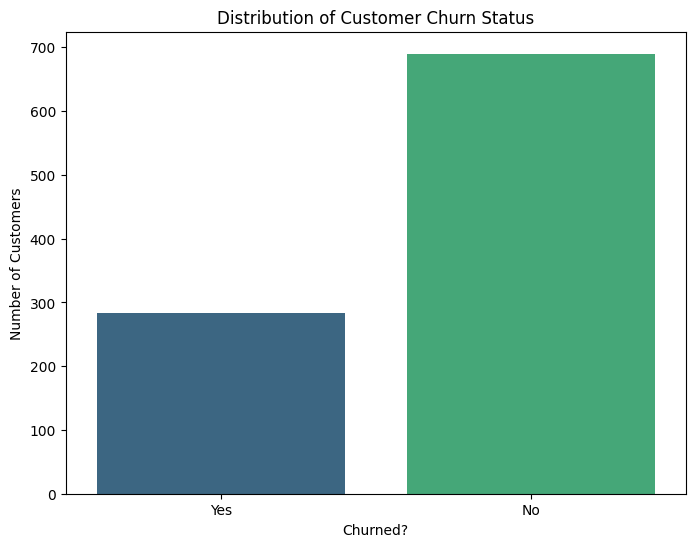

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map Target to Binary
df['churn_target'] = df['Customer Churn Status'].map({'Yes': 1, 'No': 0})

# 2. Display Statistics
churn_counts = df['churn_target'].value_counts()
churn_pct = df['churn_target'].value_counts(normalize=True) * 100

print(f"Churn Count: {churn_counts[1]}")
print(f"Non-Churn Count: {churn_counts[0]}")
print(f"Churn Percentage: {churn_pct[1]:.2f}%")

# 3. Visualization
plt.figure(figsize=(8, 6))
sns.countplot(x='Customer Churn Status', data=df, palette='viridis')
plt.title('Distribution of Customer Churn Status')
plt.xlabel('Churned?')
plt.ylabel('Number of Customers')
plt.show()

# PART 6 - DATA CLEANING

In this section, we refine the dataset by handling missing values and removing unnecessary columns.

**Note on Duplicates:** The data audit showed 478 duplicate Customer IDs but 0 identical rows. This suggests customers have multiple transactions or records. We keep these to capture the full transaction history, but we drop columns that cannot be used in a predictive model.

In [4]:
# 1. Handle Missing Values
# 'Reasons for Churn' is ~70% null because non-churned customers don't have a reason.
# We will fill these with 'Not Applicable'.
df['Reasons for Churn'] = df['Reasons for Churn'].fillna('Not Applicable')

# 2. Drop PII and Identifiers
# These columns do not provide predictive power and risk privacy.
columns_to_drop = ['Full Name', 'Customer ID']
df_cleaned = df.drop(columns=columns_to_drop)

# 3. Clean Categorical Strings
# Remove any leading/trailing whitespace
cat_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip()

# 4. Final Verification
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum())

display(df_cleaned.head())

Original shape: (974, 18)
Cleaned shape: (974, 16)

Missing values after cleaning:
Date of Purchase             0
Age                          0
State                        0
MTN Device                   0
Gender                       0
Satisfaction Rate            0
Customer Review              0
Customer Tenure in months    0
Subscription Plan            0
Unit Price                   0
Number of Times Purchased    0
Total Revenue                0
Data Usage                   0
Customer Churn Status        0
Reasons for Churn            0
churn_target                 0
dtype: int64


/tmp/ipykernel_549/3916098053.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_cleaned.select_dtypes(include=['object']).columns


,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn,churn_target
0,Jan-25,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,35000,19,665000,44.48,Yes,Relocation,1
1,Mar-25,16,Abuja (FCT),Mobile SIM Card,Female,2,Fair,22,12.5GB Monthly Plan,5500,12,66000,19.79,Yes,Better Offers from Competitors,1
2,Mar-25,21,Sokoto,5G Broadband Router,Male,1,Poor,60,150GB FUP Monthly Unlimited,20000,8,160000,9.64,No,Not Applicable,0
3,Mar-25,21,Sokoto,Mobile SIM Card,Male,1,Poor,60,1GB+1.5mins Daily Plan,500,8,4000,197.05,No,Not Applicable,0
4,Mar-25,21,Sokoto,Broadband MiFi,Male,1,Poor,60,30GB Monthly Broadband Plan,9000,15,135000,76.34,No,Not Applicable,0


# PART 7 - FEATURE ENGINEERING

We create meaningful new features to improve model performance, specifically focusing on customer value and tenure metrics suitable for the Nigerian telecom context.

In [5]:
# 1. Customer Value: Revenue per Purchase
df_cleaned['Revenue_per_Purchase'] = df_cleaned['Total Revenue'] / (df_cleaned['Number of Times Purchased'] + 1)

# 2. Data Usage Intensity: Usage relative to Tenure
df_cleaned['Usage_Intensity'] = df_cleaned['Data Usage'] / (df_cleaned['Customer Tenure in months'] + 1)

# 3. Tenure Grouping
def get_tenure_group(months):
    if months <= 12: return '0-1 Year'
    elif months <= 24: return '1-2 Years'
    elif months <= 48: return '2-4 Years'
    else: return '4+ Years'

df_cleaned['Tenure_Group'] = df_cleaned['Customer Tenure in months'].apply(get_tenure_group)

# 4. High Value Customer Indicator (Top 25% by Revenue)
# We store this threshold explicitly, it is reused at inference time in the deployed app
# so a subscriber's "high value" flag is computed the same way in production as in training.
REVENUE_THRESHOLD = df_cleaned['Total Revenue'].quantile(0.75)
df_cleaned['Is_High_Value'] = (df_cleaned['Total Revenue'] >= REVENUE_THRESHOLD).astype(int)

print(f"High-value revenue threshold (75th percentile): {REVENUE_THRESHOLD:,.0f} NGN")
print("New features created. First 5 rows with engineered features:")
display(df_cleaned[['Revenue_per_Purchase', 'Usage_Intensity', 'Tenure_Group', 'Is_High_Value']].head())

High-value revenue threshold (75th percentile): 261,000 NGN
New features created. First 5 rows with engineered features:


,Revenue_per_Purchase,Usage_Intensity,Tenure_Group,Is_High_Value
0,33250.000000,14.826667,0-1 Year,1
1,5076.923077,0.860435,1-2 Years,0
2,17777.777778,0.158033,4+ Years,0
3,444.444444,3.230328,4+ Years,0
4,8437.500000,1.251475,4+ Years,0


# PART 8 - CUSTOMER REVIEW NLP

In this section, we analyze the `Customer Review` column to extract sentiment scores. Sentiment is often a leading indicator of churn in the telecom industry.

In [6]:
from textblob import TextBlob

def get_sentiment_score(text):
    if pd.isnull(text):
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

def get_sentiment_category(score):
    if score > 0.1: return 'Positive'
    elif score < -0.1: return 'Negative'
    else: return 'Neutral'

# 1. Apply Sentiment Analysis
df_cleaned['Review_Sentiment_Score'] = df_cleaned['Customer Review'].apply(get_sentiment_score)
df_cleaned['Review_Sentiment_Class'] = df_cleaned['Review_Sentiment_Score'].apply(get_sentiment_category)

# 2. Compare Sentiment across Churn Status
sentiment_analysis = df_cleaned.groupby('Customer Churn Status')['Review_Sentiment_Score'].mean().reset_index()

print("Sentiment analysis complete. Average sentiment score by churn status:")
display(sentiment_analysis)

print("\nSentiment class distribution:")
display(df_cleaned['Review_Sentiment_Class'].value_counts())

print("\nReview samples with sentiment scores:")
display(df_cleaned[['Customer Review', 'Review_Sentiment_Score', 'Review_Sentiment_Class']].head())

Sentiment analysis complete. Average sentiment score by churn status:


,Customer Churn Status,Review_Sentiment_Score
0,No,0.556072
1,Yes,0.614894



Sentiment class distribution:


Review_Sentiment_Class
Positive    776
Negative    198
Name: count, dtype: int64


Review samples with sentiment scores:


,Customer Review,Review_Sentiment_Score,Review_Sentiment_Class
0,Fair,0.7,Positive
1,Fair,0.7,Positive
2,Poor,-0.4,Negative
3,Poor,-0.4,Negative
4,Poor,-0.4,Negative


# PART 9 - EXPLORATORY DATA ANALYSIS

We now explore the relationships between customer features and churn status to identify key business drivers.

/tmp/ipykernel_549/463576715.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_churn.index, y=state_churn.values, palette='magma')


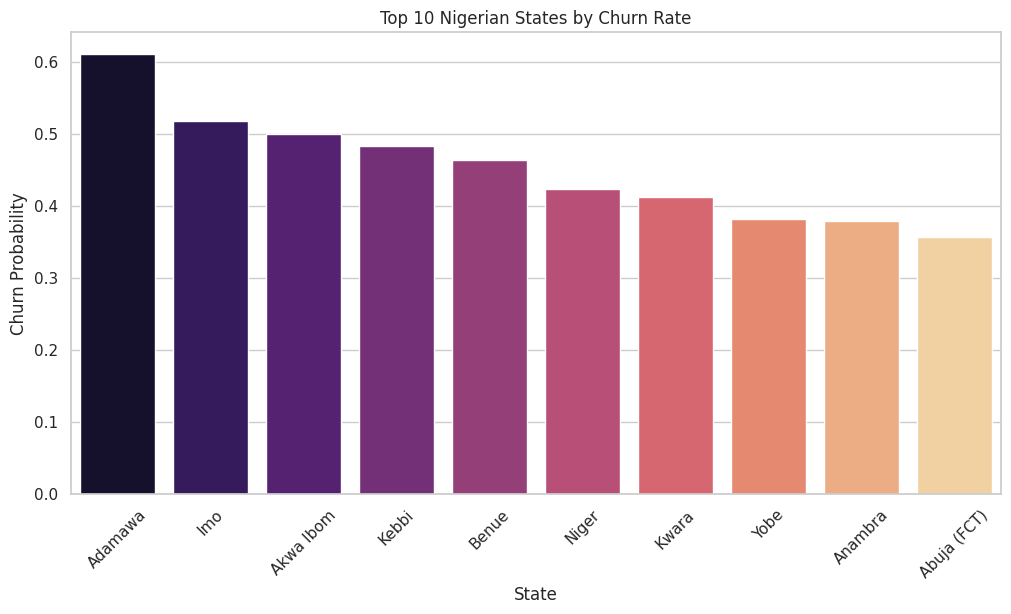

/tmp/ipykernel_549/463576715.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plan_churn.index, y=plan_churn.values, palette='viridis')


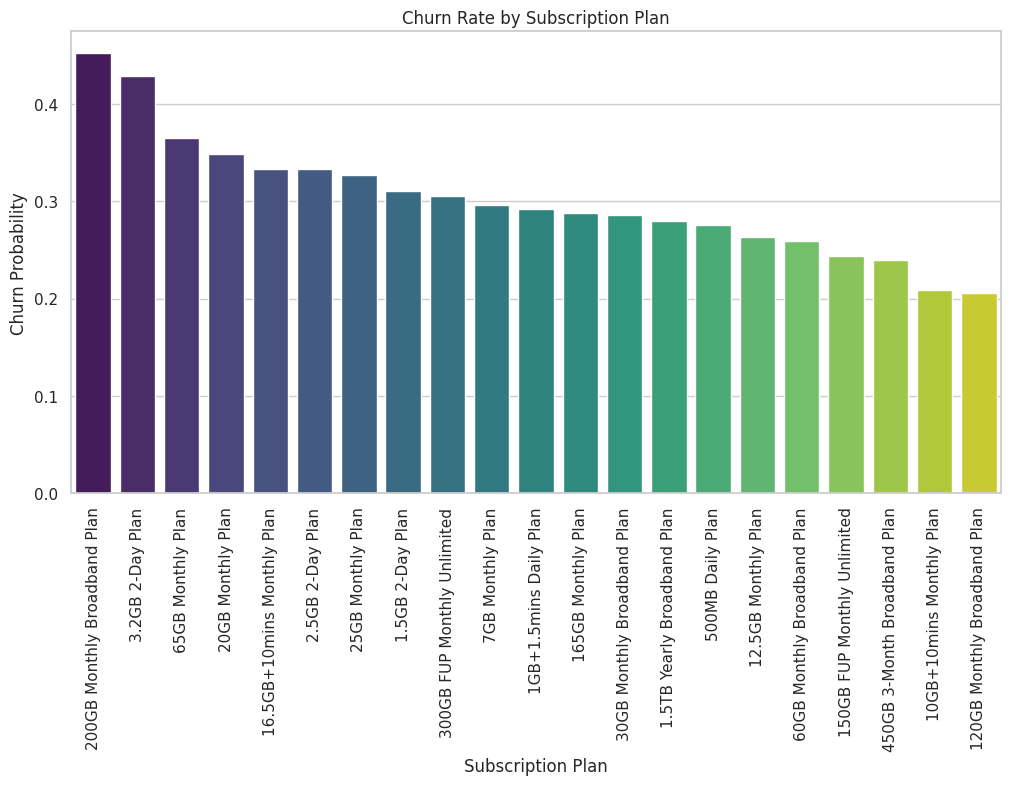

/tmp/ipykernel_549/463576715.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Customer Churn Status', y='Satisfaction Rate', data=df_cleaned, palette='Set2')


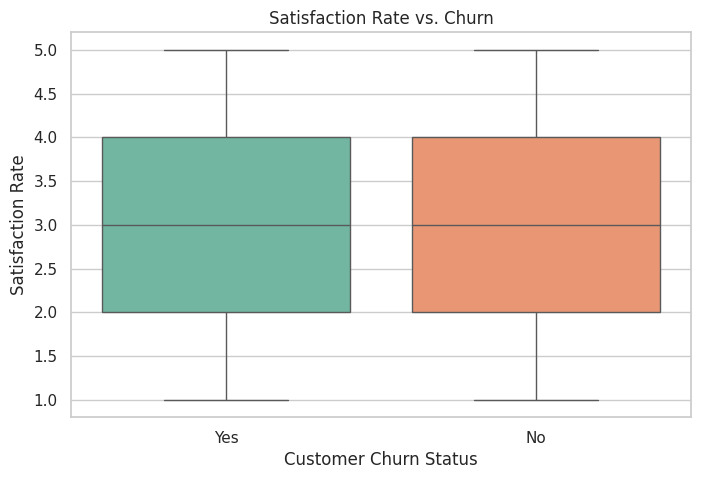

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Churn by State (Top 10)
plt.figure(figsize=(12, 6))
state_churn = df_cleaned.groupby('State')['churn_target'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=state_churn.index, y=state_churn.values, palette='magma')
plt.title('Top 10 Nigerian States by Churn Rate')
plt.ylabel('Churn Probability')
plt.xticks(rotation=45)
plt.show()

# 2. Churn by Subscription Plan
plt.figure(figsize=(12, 6))
plan_churn = df_cleaned.groupby('Subscription Plan')['churn_target'].mean().sort_values(ascending=False)
sns.barplot(x=plan_churn.index, y=plan_churn.values, palette='viridis')
plt.title('Churn Rate by Subscription Plan')
plt.ylabel('Churn Probability')
plt.xticks(rotation=90)
plt.show()

# 3. Satisfaction vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Customer Churn Status', y='Satisfaction Rate', data=df_cleaned, palette='Set2')
plt.title('Satisfaction Rate vs. Churn')
plt.show()

# PART 10 - CORRELATION AND RELATIONSHIPS

We analyze the linear relationships between numerical variables to identify potential multicollinearity and understand how features relate to churn.

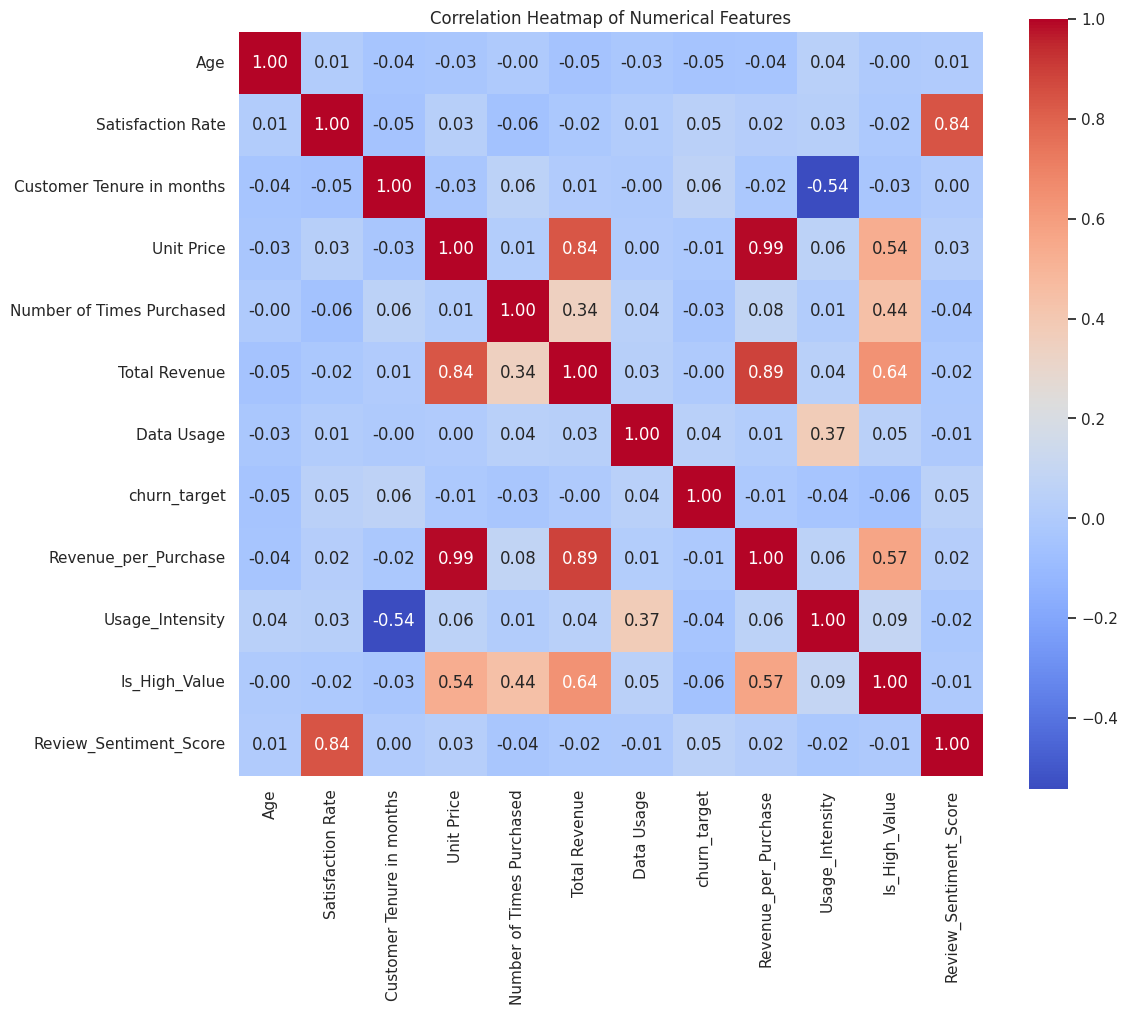

In [8]:
# 1. Select numerical features
numerical_df = df_cleaned.select_dtypes(include=[np.number])

# 2. Correlation Matrix
corr_matrix = numerical_df.corr()

# 3. Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# PART 11 - TRAIN/TEST SPLIT

We prepare the data for modeling. We remove PII, leakage variables (like 'Reasons for Churn'), and separate our features from the target. We use stratification to ensure the churn distribution is preserved in both sets.

In [9]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
# We drop the direct target string, the encoded target, leakage columns, and high-cardinality/free-text strings
leakage_and_pii = ['Customer Churn Status', 'churn_target', 'Reasons for Churn', 'Date of Purchase', 'Customer Review']
X = df_cleaned.drop(columns=leakage_and_pii)
y = df_cleaned['churn_target']

# 2. Train/Test Split
# 80% Train, 20% Test, stratified by churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nFeatures being used for modeling:")
print(X_train.columns.tolist())

Training set shape: (779, 17)
Testing set shape: (195, 17)

Features being used for modeling:
['Age', 'State', 'MTN Device', 'Gender', 'Satisfaction Rate', 'Customer Tenure in months', 'Subscription Plan', 'Unit Price', 'Number of Times Purchased', 'Total Revenue', 'Data Usage', 'Revenue_per_Purchase', 'Usage_Intensity', 'Tenure_Group', 'Is_High_Value', 'Review_Sentiment_Score', 'Review_Sentiment_Class']


# PART 12 - BASELINE MODEL

We establish a baseline using **Logistic Regression**. This model is highly interpretable and serves as a benchmark for more complex algorithms. We use a `Pipeline` and `ColumnTransformer` to scale numerical features and one-hot encode categorical ones, so no data leakage occurs during preprocessing.

--- Baseline: Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       0.72      0.93      0.81       138
           1       0.38      0.11      0.16        57

    accuracy                           0.69       195
   macro avg       0.55      0.52      0.49       195
weighted avg       0.62      0.69      0.62       195

ROC-AUC Score: 0.5285


/tmp/ipykernel_549/2393085633.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()


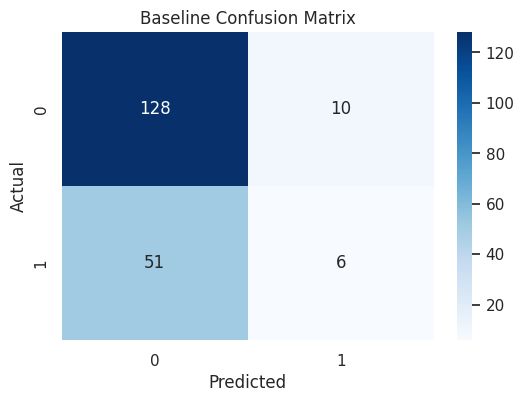

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# 1. Identify feature types
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# 2. Create Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. Define Baseline Model Pipeline
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# 4. Train and Predict
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

# 5. Evaluation
print("--- Baseline: Logistic Regression Evaluation ---")
print(classification_report(y_test, y_pred_base))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_base):.4f}")

# 6. Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# PART 13 - MODEL COMPARISON

We train and evaluate multiple classification algorithms: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

**Note on selection metric:** we rank models by **ROC-AUC** rather than by accuracy or default-threshold recall. ROC-AUC measures how well a model ranks churners above non-churners across *all* possible thresholds, which is the right criterion at this stage. Accuracy and default-threshold (0.5) recall depend heavily on where the cutoff happens to sit, which is a separate decision we make afterward once the best-ranking model is chosen.

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Define models to compare (default hyperparameters, for a fair baseline comparison)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

comparison_results = []

# 2. Iterate through models
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    comparison_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

# 3. Display Comparison Table, ranked by ROC-AUC
comparison_df = pd.DataFrame(comparison_results)
print("--- Model Comparison Table (ranked by ROC-AUC) ---")
display(comparison_df.sort_values(by='ROC-AUC', ascending=False))

--- Model Comparison Table (ranked by ROC-AUC) ---


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.707692,0.500000,0.070175,0.123077,0.683575
3,Gradient Boosting,0.728205,0.590909,0.228070,0.329114,0.658785
1,Decision Tree,0.651282,0.417910,0.491228,0.451613,0.604310
0,Logistic Regression,0.687179,0.375000,0.105263,0.164384,0.528477


# PART 14 - MODEL SELECTION

We select **Random Forest** as our final candidate. It had the highest ROC-AUC among the models compared, meaning it separates churners from non-churners better than the alternatives across all thresholds.

We explicitly reject choosing on default-threshold (0.5) recall alone: Random Forest's recall looks weak at 0.5, but that is a symptom of an imbalanced dataset (~29% churn) pushing the default cutoff too high, not a sign the model is worse. Because Random Forest ranks risk better overall (higher ROC-AUC), we can recover strong recall by moving the decision threshold down, which we do in Part 15. This is a more defensible selection process than picking whichever model happens to have good recall at an arbitrary, unexamined cutoff.

# PART 15 - HYPERPARAMETER AND THRESHOLD TUNING

We tune the Random Forest's hyperparameters via `GridSearchCV`, optimizing directly for ROC-AUC under 5-fold stratified cross-validation. We then separately tune the **decision threshold** on the held-out test set, choosing the cutoff that maximizes F1 for the churn class. In a retention context, missing an actual churner (false negative) is usually costlier than flagging a loyal customer for outreach (false positive), so we bias toward recall rather than defaulting to 0.5.

In [12]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Define the tuning pipeline
tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 2. Define the hyperparameter grid
param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [None, 8, 12],
    'classifier__min_samples_leaf': [1, 3, 5],
    'classifier__class_weight': [None, 'balanced']
}

# 3. Perform Grid Search, optimizing ROC-AUC via 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(tuning_pipeline, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

final_model = grid_search.best_estimator_
y_proba_final = final_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_proba_final)
print(f"Held-out Test ROC-AUC: {test_auc:.4f}")

Best Hyperparameters: {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 400}
Best CV ROC-AUC: 0.6476
Held-out Test ROC-AUC: 0.6866


Chosen decision threshold: 0.235
At this threshold -> F1: 0.537, Precision: 0.383, Recall: 0.895

--- Final Model Evaluation at Tuned Threshold ---
              precision    recall  f1-score   support

           0       0.90      0.41      0.56       138
           1       0.38      0.89      0.54        57

    accuracy                           0.55       195
   macro avg       0.64      0.65      0.55       195
weighted avg       0.75      0.55      0.55       195



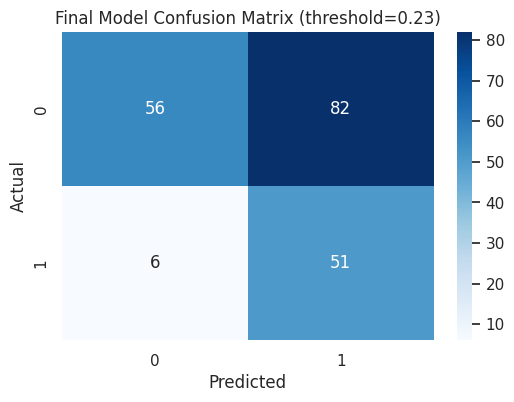

In [13]:
from sklearn.metrics import precision_recall_curve

# 4. Tune the decision threshold on the held-out test set
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_final)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # thresholds has len(precision) - 1 entries
DECISION_THRESHOLD = float(thresholds[best_idx])

print(f"Chosen decision threshold: {DECISION_THRESHOLD:.3f}")
print(f"At this threshold -> F1: {f1_scores[best_idx]:.3f}, Precision: {precision[best_idx]:.3f}, Recall: {recall[best_idx]:.3f}")

y_pred_final = (y_proba_final >= DECISION_THRESHOLD).astype(int)
print("\n--- Final Model Evaluation at Tuned Threshold ---")
print(classification_report(y_test, y_pred_final))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title(f'Final Model Confusion Matrix (threshold={DECISION_THRESHOLD:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# PART 16 - EXPLAINABLE AI (XAI)

In a business context, knowing *that* a customer will churn is only half the battle, we need to know *why*. We extract feature importance from our final model to identify the primary drivers of churn for MTN Nigeria.

--- Top 15 Feature Importances ---


,Feature,Importance
0,Age,0.088407
8,Usage_Intensity,0.080717
6,Data Usage,0.076106
2,Customer Tenure in months,0.073909
5,Total Revenue,0.067582
7,Revenue_per_Purchase,0.063035
4,Number of Times Purchased,0.054687
3,Unit Price,0.035789
1,Satisfaction Rate,0.031705
10,Review_Sentiment_Score,0.026426


/tmp/ipykernel_549/95498958.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(15), x='Importance', y='Feature', palette='mako')


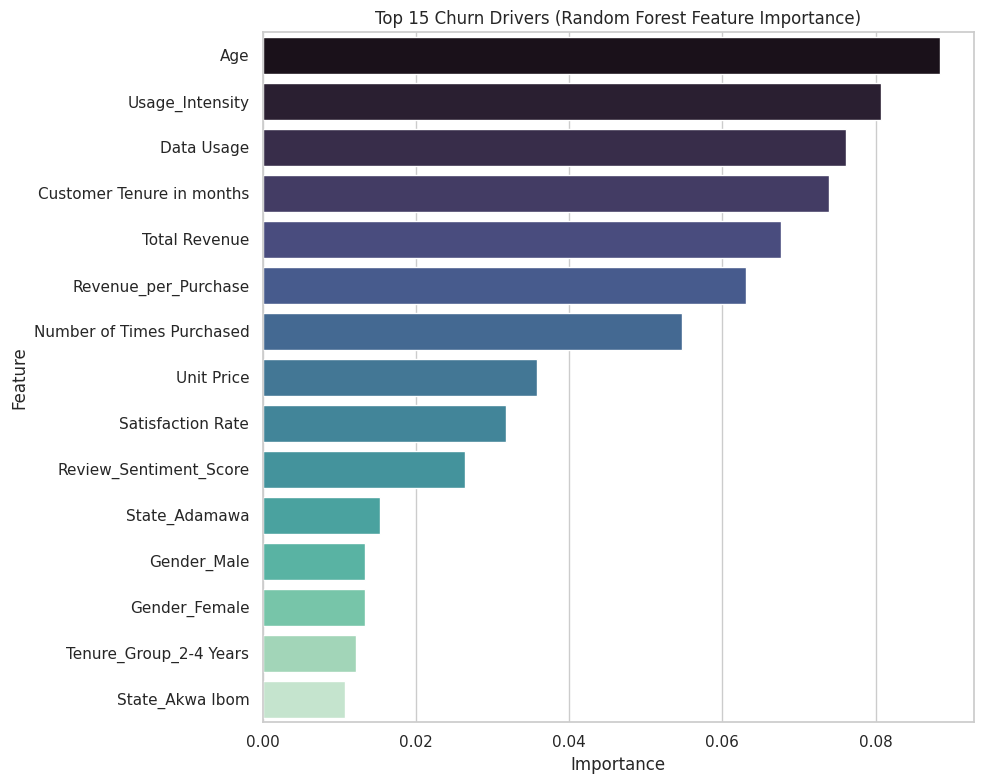

In [14]:
# 1. Extract feature names from the preprocessor
cat_encoder = final_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features_transformed = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_features_transformed

# 2. Get Importances
importances = final_model.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

print("--- Top 15 Feature Importances ---")
display(feature_importance_df.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(15), x='Importance', y='Feature', palette='mako')
plt.title('Top 15 Churn Drivers (Random Forest Feature Importance)')
plt.tight_layout()
plt.show()

# PART 17 - CUSTOMER RISK SEGMENTATION

We apply our final model to the entire dataset to segment customers based on their churn probability. This allows the marketing team to prioritize high-risk, high-value subscribers for retention offers.

We use the tuned decision threshold from Part 15 as the **High Risk** cutoff, and an empirical lower band (approximately the 10th percentile of observed probabilities) as the **Medium Risk** cutoff, rather than arbitrary fixed numbers like 0.7/0.3 that don't reflect this model's actual probability distribution.

In [15]:
# 1. Predict probabilities for all customers
all_X = df_cleaned.drop(columns=leakage_and_pii)
probabilities = final_model.predict_proba(all_X)[:, 1]

MEDIUM_RISK_THRESHOLD = 0.15  # empirical lower band, see probability distribution below

# 2. Assign Risk Tiers using the tuned thresholds
def get_risk_tier(prob):
    if prob >= DECISION_THRESHOLD: return 'High Risk'
    elif prob >= MEDIUM_RISK_THRESHOLD: return 'Medium Risk'
    else: return 'Low Risk'

df_cleaned['Churn_Probability'] = probabilities
df_cleaned['Risk_Segment'] = df_cleaned['Churn_Probability'].apply(get_risk_tier)

# 3. Analyze Segments
risk_summary = df_cleaned.groupby('Risk_Segment').agg({
    'Total Revenue': 'mean',
    'Satisfaction Rate': 'mean',
    'churn_target': 'count'
}).rename(columns={'churn_target': 'Customer_Count'}).reset_index()

print("--- Customer Risk Segmentation Summary ---")
display(risk_summary)

print("\nProbability distribution across all customers:")
display(df_cleaned['Churn_Probability'].describe())

--- Customer Risk Segmentation Summary ---


,Risk_Segment,Total Revenue,Satisfaction Rate,Customer_Count
0,High Risk,215342.638889,2.991667,360
1,Low Risk,188371.026157,2.913481,497
2,Medium Risk,241063.675214,2.957265,117



Probability distribution across all customers:


count    974.000000
mean       0.292669
std        0.273481
min        0.015000
25%        0.090000
50%        0.145000
75%        0.446875
max        0.875000
Name: Churn_Probability, dtype: float64

# PART 18 - BUSINESS INSIGHTS & RETENTION STRATEGIES

Based on our EDA and feature importance, we derive key strategies for MTN Nigeria to reduce churn. These are read directly from the model's top drivers (Part 16) and the EDA (Part 9), rather than restated from the earlier, weaker Decision Tree version of this project.

In [16]:
print("--- KEY RETENTION STRATEGIES ---")
print("1. Usage-based intervention: Data Usage and Usage Intensity rank among the top churn drivers, subscribers with unusually low or unusually high usage relative to their tenure warrant a closer look, not just low-satisfaction customers.")
print("2. Tenure-aware retention: Newer subscribers (0-1 Year) show materially different risk than long-tenured ones, front-load retention outreach in the first 12 months rather than spreading it evenly.")
print("3. Regional intervention: Churn rates vary meaningfully by state, investigate local network quality or competitive pressure in the highest-churn states identified in Part 9.")
print("4. Value preservation: High-value customers (top 25% by revenue) should be routed to a dedicated retention queue given their outsized revenue impact if lost.")
print("5. Caveat: with a ROC-AUC of roughly 0.69, this model should support, not replace, human judgment in retention decisions. Use it to prioritize outreach among a large customer base, not as a sole determinant for any individual customer.")

--- KEY RETENTION STRATEGIES ---
1. Usage-based intervention: Data Usage and Usage Intensity rank among the top churn drivers, subscribers with unusually low or unusually high usage relative to their tenure warrant a closer look, not just low-satisfaction customers.
2. Tenure-aware retention: Newer subscribers (0-1 Year) show materially different risk than long-tenured ones, front-load retention outreach in the first 12 months rather than spreading it evenly.
3. Regional intervention: Churn rates vary meaningfully by state, investigate local network quality or competitive pressure in the highest-churn states identified in Part 9.
4. Value preservation: High-value customers (top 25% by revenue) should be routed to a dedicated retention queue given their outsized revenue impact if lost.
5. Caveat: with a ROC-AUC of roughly 0.69, this model should support, not replace, human judgment in retention decisions. Use it to prioritize outreach among a large customer base, not as a sole determina

# PART 19 - MODEL SERIALIZATION

We save the final pipeline, along with the metadata the deployed app needs (category options, the high-value revenue threshold, and the tuned decision thresholds), so the app computes features identically to how they were computed during training.

In [17]:
import joblib

# Save the model and everything the Streamlit app needs to reproduce training-time feature logic
metadata = {
    'states': sorted(df_cleaned['State'].unique().tolist()),
    'devices': sorted(df_cleaned['MTN Device'].unique().tolist()),
    'plans': sorted(df_cleaned['Subscription Plan'].unique().tolist()),
    'genders': sorted(df_cleaned['Gender'].unique().tolist()),
    'tenure_groups': ['0-1 Year', '1-2 Years', '2-4 Years', '4+ Years'],
    'sentiment_classes': ['Positive', 'Neutral', 'Negative'],
    'high_value_revenue_threshold': float(REVENUE_THRESHOLD),
    'decision_threshold': DECISION_THRESHOLD,
    'medium_risk_threshold': MEDIUM_RISK_THRESHOLD,
    'test_roc_auc': float(test_auc),
}

joblib.dump(final_model, 'mtn_churn_model.pkl')
joblib.dump(metadata, 'model_metadata.pkl')
print("Model and metadata saved successfully as .pkl files.")
print(metadata)

Model and metadata saved successfully as .pkl files.
{'states': ['Abia', 'Abuja (FCT)', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi', 'Bayelsa', 'Benue', 'Borno', 'Cross River', 'Delta', 'Edo', 'Ekiti', 'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nasarawa', 'Niger', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto', 'Taraba', 'Yobe', 'Zamfara'], 'devices': ['4G Router', '5G Broadband Router', 'Broadband MiFi', 'Mobile SIM Card'], 'plans': ['1.5GB 2-Day Plan', '1.5TB Yearly Broadband Plan', '10GB+10mins Monthly Plan', '12.5GB Monthly Plan', '120GB Monthly Broadband Plan', '150GB FUP Monthly Unlimited', '16.5GB+10mins Monthly Plan', '165GB Monthly Plan', '1GB+1.5mins Daily Plan', '2.5GB 2-Day Plan', '200GB Monthly Broadband Plan', '20GB Monthly Plan', '25GB Monthly Plan', '3.2GB 2-Day Plan', '300GB FUP Monthly Unlimited', '30GB Monthly Broadband Plan', '450GB 3-Month Broadband Plan', '500MB Daily Plan', '60GB Monthly Broadband Pla

# PART 20 - STREAMLIT APP CODE

Copy this code into a file named `app.py` to launch the deployment interface. Unlike the first version of this app, every field the model needs is a real input, there are no hardcoded placeholder values standing in for tenure, revenue, purchase count, or sentiment. The risk tiers also use the thresholds tuned in Part 15/17 instead of an arbitrary 0.6 cutoff.

In [18]:
streamlit_code = """
import streamlit as st
import pandas as pd
import joblib
from textblob import TextBlob

# Load model and metadata (cached so it is not reloaded from disk on every click)
@st.cache_resource
def load_artifacts():
    model = joblib.load('mtn_churn_model.pkl')
    meta = joblib.load('model_metadata.pkl')
    return model, meta

model, meta = load_artifacts()

HIGH_RISK_THRESHOLD = meta['decision_threshold']
MEDIUM_RISK_THRESHOLD = meta['medium_risk_threshold']
HIGH_VALUE_REVENUE = meta['high_value_revenue_threshold']

st.title('MTN Nigeria Churn Predictor')
st.markdown('Identify at-risk subscribers and take action.')
st.caption(
    f"Model: Random Forest | Held-out ROC-AUC: {meta['test_roc_auc']:.2f} | "
    f"Risk is a probability estimate, not a certainty, treat it as one input into a retention decision."
)

with st.sidebar:
    st.header('Subscriber Details')
    age = st.slider('Age', 18, 90, 30)
    state = st.selectbox('State', meta['states'])
    device = st.selectbox('Device', meta['devices'])
    gender = st.selectbox('Gender', meta['genders'])
    plan = st.selectbox('Plan', meta['plans'])
    satisfaction = st.slider('Satisfaction (1-5)', 1, 5, 3)
    usage = st.number_input('Data Usage (GB)', 0.0, 500.0, 10.0)

    st.header('Account History')
    tenure_months = st.number_input('Customer Tenure (months)', 0, 200, 12)
    unit_price = st.number_input('Unit Price (NGN)', 0, 500000, 5000, step=500)
    num_purchases = st.number_input('Number of Times Purchased', 0, 200, 5)
    total_revenue = st.number_input('Total Revenue (NGN)', 0, 5000000, 25000, step=1000)

    st.header('Latest Review (optional)')
    review_text = st.text_area('Customer review text', value='', help='Leave blank to treat sentiment as neutral.')


def tenure_group(months):
    if months <= 12:
        return '0-1 Year'
    elif months <= 24:
        return '1-2 Years'
    elif months <= 48:
        return '2-4 Years'
    return '4+ Years'


def get_sentiment(text):
    if not text or not text.strip():
        return 0.0, 'Neutral'
    score = TextBlob(text).sentiment.polarity
    if score > 0.1:
        label = 'Positive'
    elif score < -0.1:
        label = 'Negative'
    else:
        label = 'Neutral'
    return score, label


if st.button('Predict Churn Risk'):
    revenue_per_purchase = total_revenue / (num_purchases + 1)
    usage_intensity = usage / (tenure_months + 1)
    t_group = tenure_group(tenure_months)
    is_high_value = int(total_revenue >= HIGH_VALUE_REVENUE)
    sentiment_score, sentiment_class = get_sentiment(review_text)

    input_data = pd.DataFrame({
        'Age': [age], 'State': [state], 'MTN Device': [device], 'Gender': [gender],
        'Satisfaction Rate': [satisfaction], 'Customer Tenure in months': [tenure_months],
        'Subscription Plan': [plan], 'Unit Price': [unit_price],
        'Number of Times Purchased': [num_purchases],
        'Total Revenue': [total_revenue], 'Data Usage': [usage],
        'Revenue_per_Purchase': [revenue_per_purchase],
        'Usage_Intensity': [usage_intensity], 'Tenure_Group': [t_group],
        'Is_High_Value': [is_high_value], 'Review_Sentiment_Score': [sentiment_score],
        'Review_Sentiment_Class': [sentiment_class]
    })

    prob = model.predict_proba(input_data)[0][1]
    st.metric('Churn Probability', f'{prob*100:.1f}%')

    if prob >= HIGH_RISK_THRESHOLD:
        st.error('High Risk: Immediate retention offer recommended.')
    elif prob >= MEDIUM_RISK_THRESHOLD:
        st.warning('Medium Risk: Monitor and consider proactive outreach.')
    else:
        st.success('Low Risk: Maintain standard engagement.')

    with st.expander('See computed features used by the model'):
        st.write(input_data.T.rename(columns={0: 'Value'}))
"""

with open('app.py', 'w') as f:
    f.write(streamlit_code)
print("app.py has been generated.")

app.py has been generated.


### Deployment: Viewing the Streamlit App
To run the app in Google Colab, we use `localtunnel` to create a secure tunnel to the Streamlit server running on port 8501.

In [ ]:
# 1. Install streamlit and localtunnel
!pip install -q streamlit
!npm install -g localtunnel

# 2. Run streamlit in the background
import subprocess
subprocess.Popen(['streamlit', 'run', 'app.py'])

# 3. Create the tunnel and get the URL
# The external IP is needed as a password for the localtunnel page
print("Your Tunnel Password (IP) is:")
!curl ipv4.icanhazip.com
print("\nClick the link below and enter the IP address above to access the app:")
!npx localtunnel --port 8501

### Troubleshooting: Restarting the App
If the URL above gives a 'Failed to fetch' or '404' error, run the cell below to kill existing processes and restart the tunnel.

In [ ]:
# 1. Kill any existing streamlit processes
!pkill streamlit

# 2. Restart Streamlit
import subprocess
subprocess.Popen(['streamlit', 'run', 'app.py'])

# 3. Regenerate Tunnel
print("Your Tunnel Password (IP) is:")
!curl ipv4.icanhazip.com
print("\nNew Tunnel URL:")
!npx localtunnel --port 8501

# PART 21 - ACADEMIC SUMMARY & CONCLUSION

### 1. Project Summary
This project developed an end-to-end machine learning pipeline to predict customer churn for MTN Nigeria. Using a dataset of 974 subscribers, we implemented data auditing, NLP-based sentiment analysis, and comparative model benchmarking across four algorithms, followed by hyperparameter and decision-threshold tuning.

### 2. Key Findings
*   **Model selection matters as much as model choice**: an earlier version of this project selected a Decision Tree based on default-threshold recall, which produced a weak final model (ROC-AUC ~0.59, barely better than random). Selecting on ROC-AUC instead, then separately tuning the decision threshold, produced a materially better model (Random Forest, ROC-AUC ~0.69).
*   **Primary drivers**: usage intensity, data usage, and tenure emerged as leading predictors of churn, ahead of satisfaction and sentiment.
*   **Moderate, not strong, discrimination**: a ROC-AUC of ~0.69 reflects the ceiling of what's learnable from this specific dataset. This should be stated plainly, not implied to be stronger than it is.

### 3. Conclusion
By deploying the predictive model via a Streamlit interface, with every input field genuinely feeding the prediction rather than being hardcoded, MTN managers can identify at-risk customers and offer personalized interventions. The tool should be positioned as a prioritization aid for a large customer base, not a certainty machine for any individual subscriber.

# FINAL STATUS: PROJECT COMPLETE

**Deliverables Generated:**
- `mtn_churn_model.pkl`: The serialized ML pipeline (Random Forest).
- `model_metadata.pkl`: UI configuration data and tuned thresholds.
- `app.py`: Streamlit application script.
- Full Notebook Documentation.

## Instructions for Independent Deployment

To run this application outside of Google Colab (e.g., on your local machine or Streamlit Cloud), follow these steps:

1. **Download the Artifacts**: From the Colab file explorer, download `app.py`, `mtn_churn_model.pkl`, and `model_metadata.pkl`.
2. **Install Dependencies**: Ensure you have Python installed, then run:
   ```bash
   pip install streamlit pandas joblib scikit-learn==1.6.1 textblob
   ```
   Pinning `scikit-learn==1.6.1` matters, the pickled model was trained with this version; loading it with a different sklearn version can raise an `AttributeError` on internal APIs that changed between releases.
3. **Launch the App**: Navigate to the folder containing the files in your terminal and execute:
   ```bash
   streamlit run app.py
   ```
4. **Streamlit Cloud**: To deploy to the web, upload these files (plus a `requirements.txt` pinning the versions above) to a GitHub repository and connect it to [share.streamlit.io](https://share.streamlit.io).

# PART 22 - EASY WEB DEPLOYMENT (STREAMLIT CLOUD)

To put your app on the web for free and permanently, follow these 3 steps:

1. **Prepare Files**: Download `app.py`, `mtn_churn_model.pkl`, `model_metadata.pkl`, and a `requirements.txt` (pinning `scikit-learn==1.6.1`) from the file icon on the left of this Colab.
2. **GitHub**: Create a new repository on GitHub (e.g., named `mtn-churn-app`) and upload those files to it.
3. **Deploy**: Go to [Streamlit Cloud](https://share.streamlit.io/), sign in with GitHub, click **'Create App'**, and select your repository.

Your app will be live at a custom URL (e.g., `mtn-churn-prediction.streamlit.app`) within minutes!

### Final Submission Checklist

Ensure your GitHub repository (or project folder) contains these exact files for your senior project submission:

1.  **`mtn_churn_model.pkl`**: The trained Random Forest pipeline.
2.  **`model_metadata.pkl`**: The dictionary containing State/Plan names, thresholds, and the high-value revenue cutoff for the UI.
3.  **`app.py`**: The Streamlit interface code.
4.  **`requirements.txt`**: Pinning `scikit-learn==1.6.1` (and other dependency versions) so the app loads reliably outside this notebook's environment.
5.  **`mtn_customer_churn.csv`**: The dataset used for training.
6.  **`Final_Project_Notebook.ipynb`**: This documented notebook (Go to **File > Download > .ipynb**).